# Shortcut Connections (Skip connection or Residual connection)

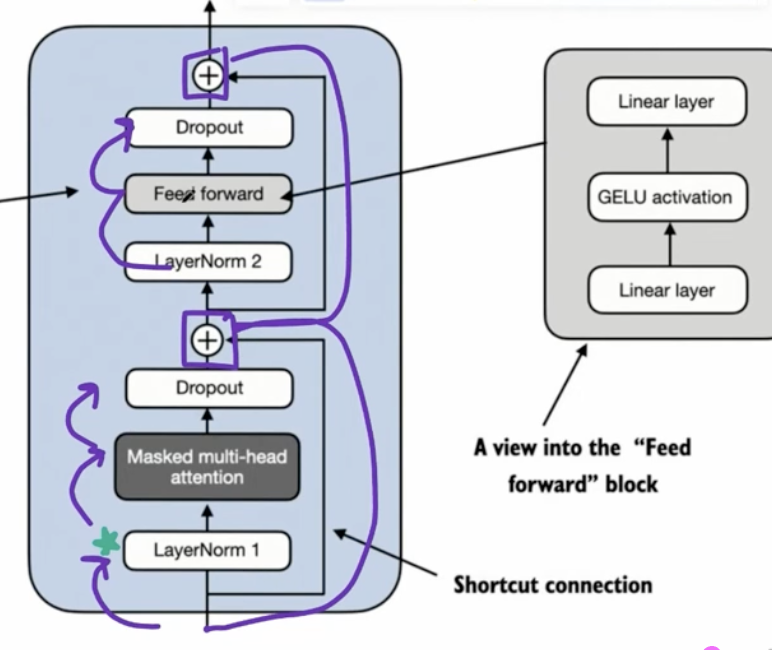

## Proposed to solve problem of vanishing gradients (gardients beacome progressively small as they propogate backward)

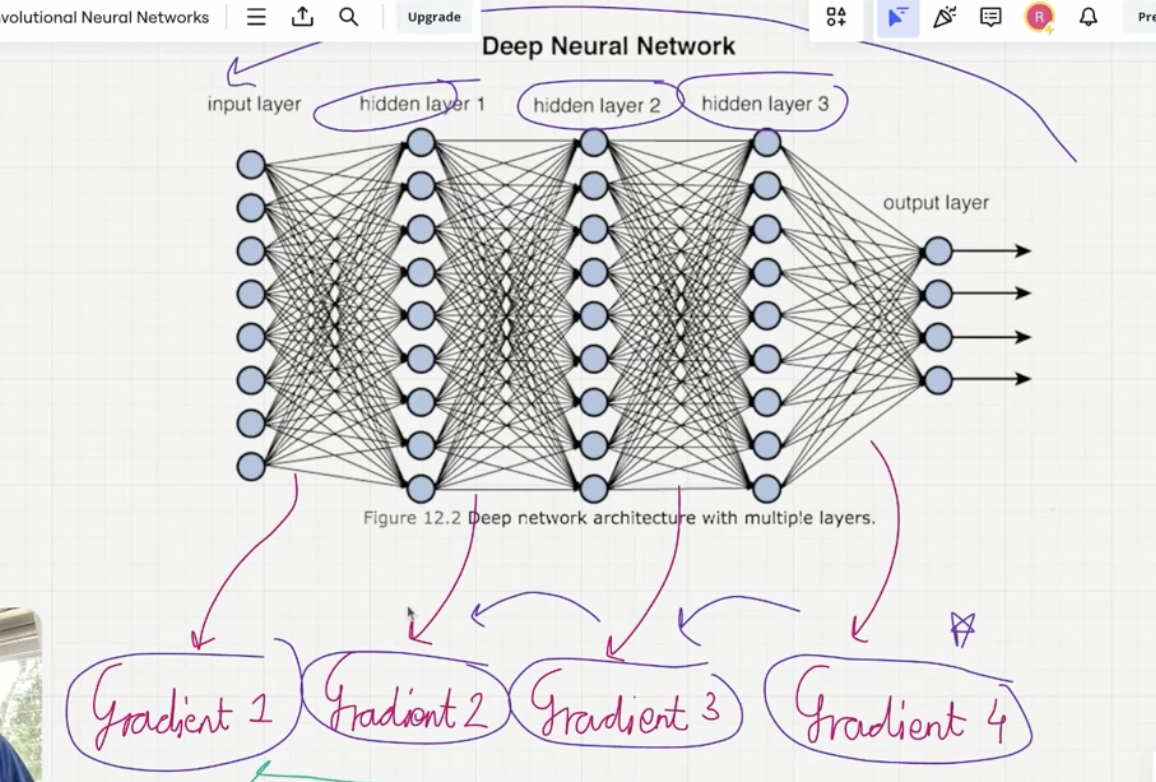

Gradient flow is backward. That is 
1. Gradient4 is used to compute Gradient3.
2. Gradient3 is used to compute Gradient2.
3. Gradient2 is used to compute Gradient1.



If suppose Gradient4 is very small , then Gradient3 will become more smaller due to dependency on Gradient4 and so on - Vanishing Gradients

If gradient appraoches to 0, then that weight becomes Stagnant


## Use of Shortcut Connections

1. Shortcut connections create an alternative path for the gradient to flow, by skipping one or more layers

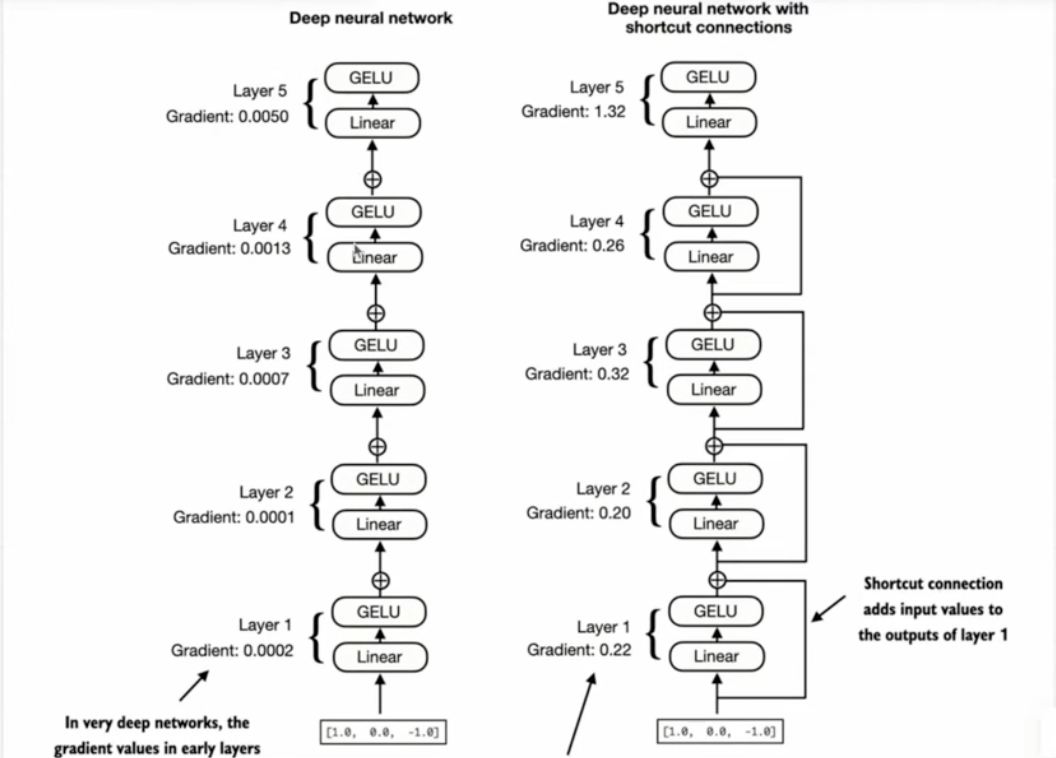

2. shortcut connections help with maintaining relatively large gradient values even in early layers

## Understanding shortcut connections

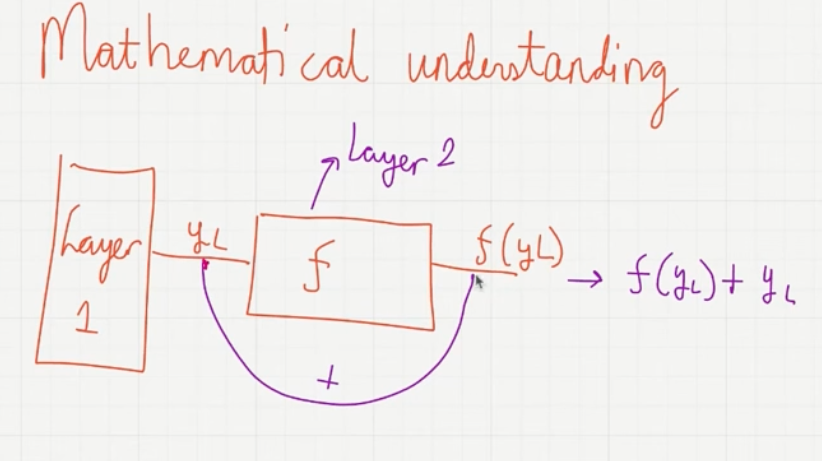
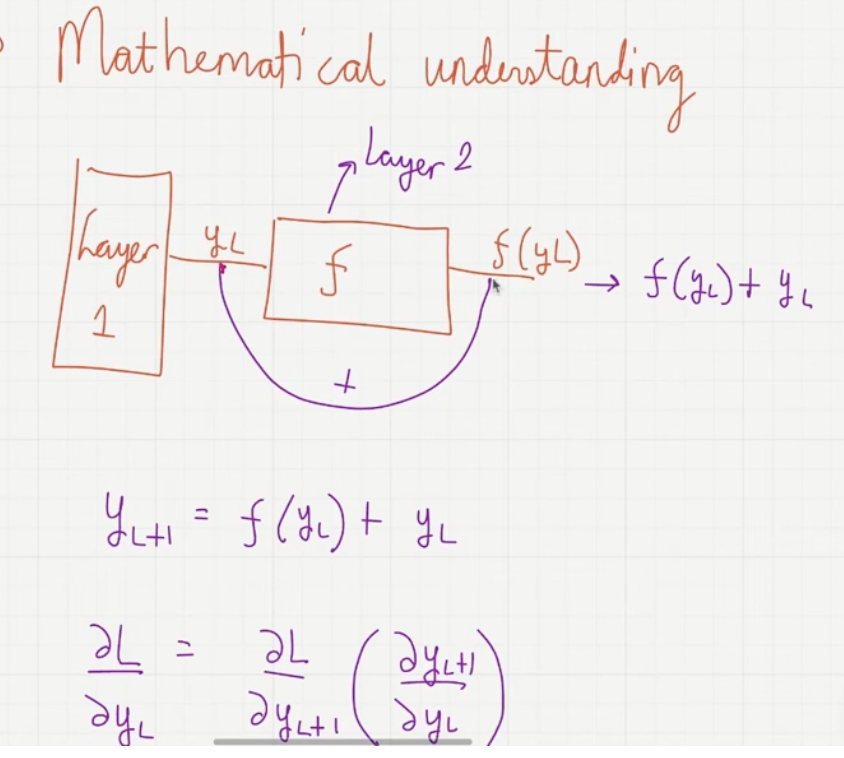

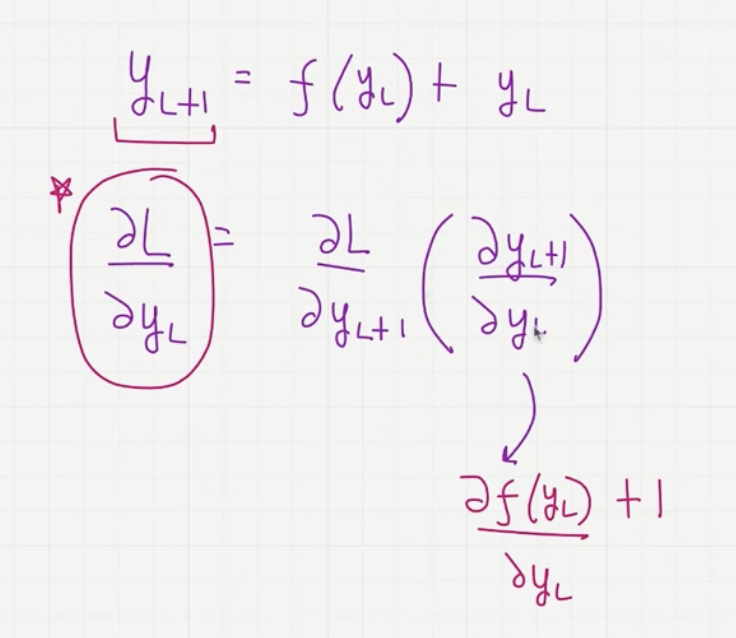

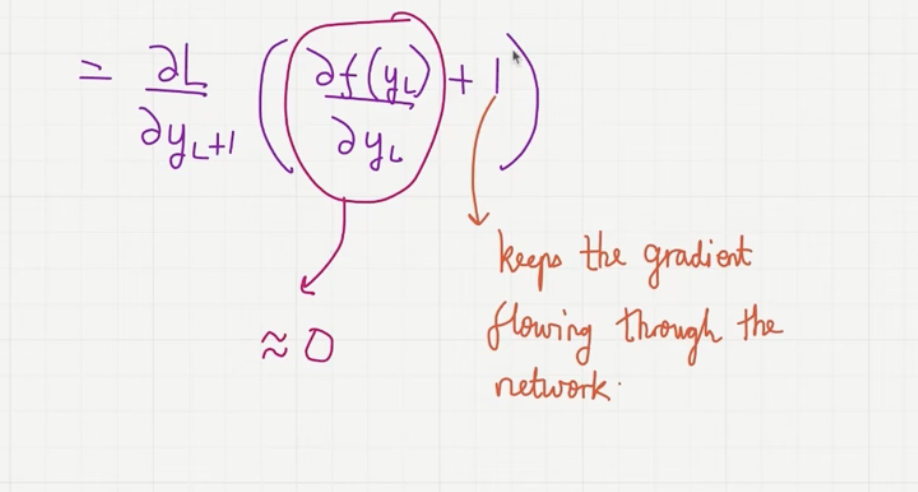

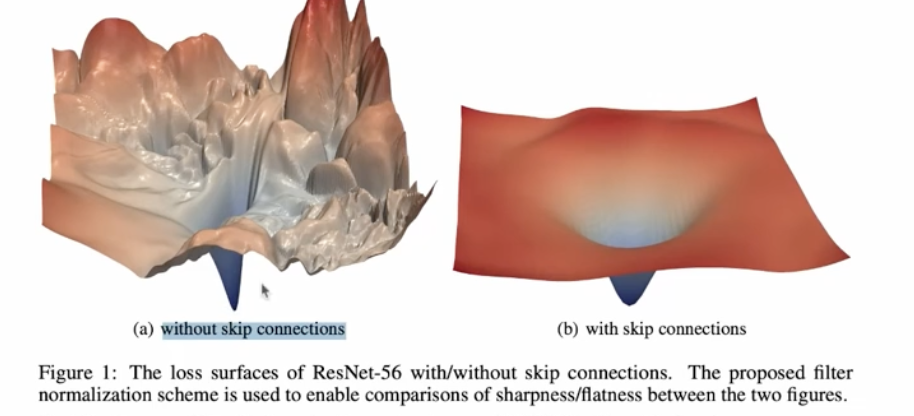

In [5]:
import torch
import torch.nn as nn

class ExampleDeepNeuralNetwork(nn.Module):

    def __init__(self,layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut

        self.layers = nn.ModuleList([
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), nn.GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), nn.GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), nn.GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), nn.GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), nn.GELU())
        ])

    def forward(self,x):
        for layer in self.layers:
            # Compute the output of the current layer
            layer_output = layer(x)
            # Check if shortcut can be applied
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x + layer_output
            else:
                x = layer_output
        return x

def print_gradients(model, x):
    # Forward pass
    output = model(x)
    target = torch.tensor([[0.]])

    # Calculate loss based on how close the target
    # and output are
    loss = nn.MSELoss()
    loss = loss(output, target)
    
    # Backward pass to calculate the gradients
    loss.backward()

    for name, param in model.named_parameters():
        if 'weight' in name:
            # Print the mean absolute gradient of the weights
            print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")


In [ ]:
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])
torch.manual_seed(123) # specify random seed for the initial weights for reproducibility

In [7]:
model_without_shortcut = ExampleDeepNeuralNetwork(
layer_sizes, use_shortcut=False
)
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.0003278696385677904
layers.1.0.weight has gradient mean of 0.0003004858735948801
layers.2.0.weight has gradient mean of 0.0006550230900757015
layers.3.0.weight has gradient mean of 0.0020961423870176077
layers.4.0.weight has gradient mean of 0.008185855112969875


In [8]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(
layer_sizes, use_shortcut=True
)
print_gradients(model_with_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22186797857284546
layers.1.0.weight has gradient mean of 0.20709271728992462
layers.2.0.weight has gradient mean of 0.3292388319969177
layers.3.0.weight has gradient mean of 0.2667771577835083
layers.4.0.weight has gradient mean of 1.3268064260482788
